## 1. Theoretical Framework & Problem Setup

Our main research objective is to analyse the causes of HDMR component approximate error.

$$
f(\mathbf{x}) + \varepsilon = y \quad \text{where} \quad \mathbb{E}[\varepsilon] = 0 \ \ \text{and} \ \ \text{Var}(\varepsilon) = \sigma^2
$$
$$
\| \hat{f}(\mathbf{x}) - y \|^2 = \| \hat{f}(\mathbf{x}) - f(\mathbf{x}) - \varepsilon \|^2
$$
$$
\int \mathbb{E}_{\varepsilon} \left[ \left( \hat{f}(x) - f(x) - \varepsilon \right)^2 \right] p(x) \, dx = \int \left(\hat{f}(x) - f(x)\right)^2 p(x) \, dx + \sigma^2 
$$

On the paper *General foundations of high‐dimensional model representations*, states that unless the higher dimenetional components are added to the general representation function, the error will be bound $\mathcal{O}(\epsilon)$ in the lower components. Therefore the constructed error can be demonstrated in two main parts:
$$
\int \left(f(\mathbf{x}) - \hat{f}(\mathbf{x})\right)^2 p(\mathbf{x}) d\mathbf{x} = \underbrace{\mathcal{O}(\epsilon)}_{\text{Unavoidable 3rd+ Order Omissions}} + \underbrace{\text{Coordinate Alignment}}_{\text{Mismatched Projection Window}}
$$
So that error is also correlated with p(x) *the weight of empirical distribution*. And throughout this notebook, we will focus on the methods of reducing mismatched projection errors.

In [1]:
import sympy as sp
import numpy as np

import utils
import importlib

# It is mandatory to execute this line of code after each change made in utils.py file.
importlib.reload(utils)

X = np.array([sp.symbols(f"x{i}") for i in range(3)])

f = X[0] * (X[1] + 1)+ X[2]*10

a = np.array([-1, -2, -1])
b = np.array([2, 2, 1])

f_mean, (f0, f1, f2), (f01, f02, f12), D, Di, Dij = utils.function_decompose(f, X, a, b)

# Sanity Check
print(
    "All components must have zero mean: ",
    sp.integrate(f0, *np.c_[X,a,b][[0]]) == 0, sp.integrate(f1, *np.c_[X,a,b][[1]]) == 0, sp.integrate(f2, *np.c_[X,a,b][[2]]) == 0,
    sp.integrate(f01, *np.c_[X,a,b][[0,1]]) == 0, sp.integrate(f02, *np.c_[X,a,b][[0,2]]) == 0, sp.integrate(f12, *np.c_[X,a,b][[1,2]]) == 0,
    f"\nThe sum of Sabrial indexies is: {Di.sum() + Dij.sum():.1f}",
)

f_hat = f_mean + sum([f0, f1, f2]) + sum([f01, f02, f12])
f_hat2 = f_mean + sum([f0, f1, f2])

error  = sp.integrate((f - f_hat)**2, *np.c_[X,a,b])
error2 = sp.integrate((f - f_hat2)**2, *np.c_[X,a,b])
print("="*10, " Uniform ", "="*10)
print(f"As f_hat equals to `f_mean + fi + fij` The error is: {error:.1f}")
print(f"As f_hat equals to `f_mean + fi` The error is: {error2:.1f}")
print(f"Sabol indexies of (f01, f02, f12) are: {Dij}")
print(f"Sabol indexies of (f0, f1, f2) are: {Di}")

All components must have zero mean:  True True True True True True 
The sum of Sabrial indexies is: 1.0
==========  Uniform  ==========
As f_hat equals to `f_mean + fi + fij` The error is: 0.0
As f_hat equals to `f_mean + fi` The error is: 24.0
Sabol indexies of (f01, f02, f12) are: [0.0282352941176471 0 0]
Sabol indexies of (f0, f1, f2) are: [0.0211764705882353 0.00941176470588235 0.941176470588235]


These results illustrate how correlations underlying the effect on the model actually affects the duel-represent components **fij**.

In generall, the only reason of increase at fij might not be correlated relations of features, but also how those independent features disturbed.

In this example we used $X_i \sim \text{U}(a_i, b_i) \quad \text{for } i = 1, 2, \dots, 8$.
In the following code, I want to show how represented function might be affect by selected distributions.

In [2]:
f_mean, (f0, f1, f2), (f01, f02, f12), D, Di, Dij = utils.function_decompose(f, X, a, b, w_type="parabolic")
f_hat = f_mean + sum([f0, f1, f2]) + sum([f01, f02, f12])
f_hat2 = f_mean + sum([f0, f1, f2])

error  = sp.integrate((f - f_hat)**2, *np.c_[X,a,b])
error_without_fij = sp.integrate((f - f_hat2)**2, *np.c_[X,a,b])

print("="*10, " Parabolic ", "="*10)
print(f"As f_hat equals to `f_mean + fi + fij` The error is: {error:.1f}")
print(f"As f_hat equals to `f_mean + fi` The error is: {error_without_fij:.1f}")
print(f"Sabol indexies of (f01, f02, f12) are: {Dij}")
print(f"Sabol indexies of (f0, f1, f2) are: {Di}")

f_mean, (f0, f1, f2), (f01, f02, f12), D, Di, Dij = utils.function_decompose(f, X, a, b, w_type="slanted")
f_hat = f_mean + sum([f0, f1, f2]) + sum([f01, f02, f12])
f_hat2 = f_mean + sum([f0, f1, f2])

error  = sp.integrate((f - f_hat)**2, *np.c_[X,a,b])
error_without_fij = sp.integrate((f - f_hat2)**2, *np.c_[X,a,b])
print("="*10, " Slanted ", "="*10)
print(f"As f_hat equals to `f_mean + fi + fij` The error is: {error:.1f}")
print(f"As f_hat equals to `f_mean + fi` The error is: {error_without_fij:.1f}")
print(f"Sabol indexies of (f01, f02, f12) are: {Dij}")
print(f"Sabol indexies of (f0, f1, f2) are: {Di}")

==========  Parabolic  ==========
As f_hat equals to `f_mean + fi + fij` The error is: 0.0
As f_hat equals to `f_mean + fi` The error is: 24.0
Sabol indexies of (f01, f02, f12) are: [36/2101 0 0]
Sabol indexies of (f0, f1, f2) are: [45/2101 20/2101 2000/2101]
==========  Slanted  ==========
As f_hat equals to `f_mean + fi + fij` The error is: 0.0
As f_hat equals to `f_mean + fi` The error is: 42.7
Sabol indexies of (f01, f02, f12) are: [8/449 0 0]
Sabol indexies of (f0, f1, f2) are: [25/449 16/449 400/449]


From the shared distribution, we derived X and y correlations, and divided them into two categroies.

Normalization step applied to the features across both training and testing row matrices.

Model arthitecture is choosen Simple *Linear(8,32)->ReLU()-> Linear(32,16)->ReLU()->Linear(16,1)*, with 8 features.

The function is extracted from the model below.

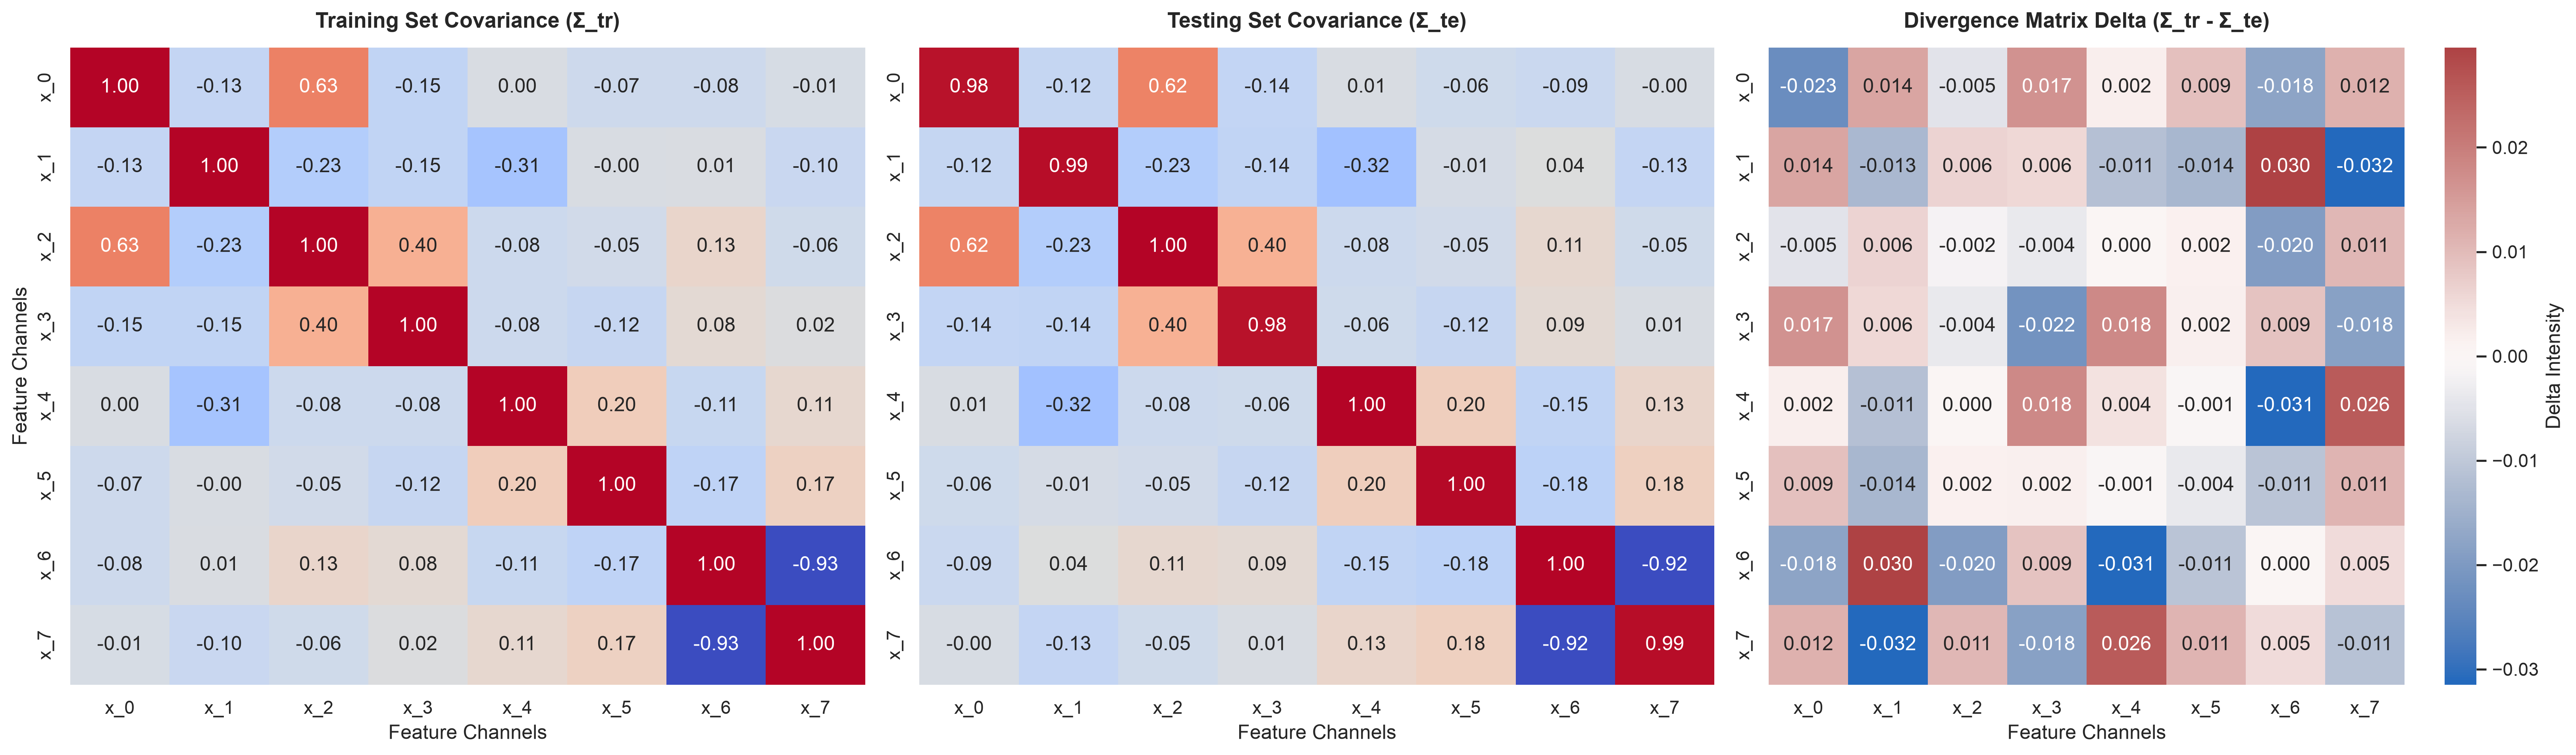

Model Loss:0.3578 | Chance loss:1.3107


In [3]:
importlib.reload(utils)
Xtr, ytr, Xte, yte = utils.return_preprocessed_data()
function, _ = utils.train_model(Xtr, ytr)

score  = ((function(*Xte) - yte)**2).mean()
chance = ((ytr.mean() - yte)**2).mean()
print(f"Model Loss:{score:.4f} | Chance loss:{chance:.4f}")

As seen in the plots, Xtr and Xte are derived from the same distribution. Both values preprocessed and normalized to give zero mean with one standart deviation for each row independently. shapes are (8, 16512) and (8, 4128) respectiely. More than that, now we have another correlation:
$$
\| \hat{f}(\mathbf{X}_{\text{te}}) - \mathbf{y}_{\text{te}} \|^2 = \| \hat{f}(\mathbf{X}_{\text{te}}) - f(\mathbf{X}_{\text{te}}) \|^2 + \sigma^2
$$
But this correlation completly up to the function distances $\| \hat{f}(\mathbf{X}_{\text{te}}) - f(\mathbf{X}_{\text{te}}) \|^2$. Apart from adding more high ordered components, another reducable error is finding proper w(x) that represents the model well.

To verify the underlying coordinate architecture, we extract the structural parameters (minima a, maxima b, standard deviation σ, and mean μ) across the feature channels of our training features.

In [4]:
import numpy as np

# Lowerbounds and Upperbounds, shapes are (8,), (8,)
a = Xtr.min(axis=1)  
b = Xtr.max(axis=1)

# Extracting attributes across features.
sigma = Xtr.std(axis=1, ddof=1)
mu    = Xtr.mean(axis=1)
cov_real = np.cov(Xtr.T)

def results(f_mimic):
    f_real  = function(*Xte)
    func_loss = np.mean((f_real - f_mimic)**2)
    real_loss = np.mean((f_mimic - yte)**2)
    print(f"The loss of how f^(Xte) close to f(Xte): {func_loss:.4f}\nThe loss of how f^(Xte) close to yte: {real_loss:.4f}")

# A view of the attributes of trained distiributions of the function.
print(f"\n>>> Xte.shape\n{Xte.shape}")
print(f"\n>>> [a, b, µ, 𝜎]\n{np.c_[a, b, sigma, mu]}")


num_vals, num_res = Xte.shape


>>> Xte.shape
(8, 4128)

>>> [a, b, µ, 𝜎]
[[-1.85599857e+00  3.71005547e+00  1.00003028e+00 -1.22938575e-14]
 [-2.19076551e+00  1.85617335e+00  1.00003028e+00 -6.68608149e-17]
 [-3.34917273e+00  3.74772606e+00  1.00003028e+00  2.87860417e-14]
 [-4.65674188e+00  6.51125838e+00  1.00003028e+00 -9.20001939e-15]
 [-1.44094817e+00  4.51711559e+00  1.00003028e+00  1.81567724e-15]
 [-3.02028671e+00  3.39388168e+00  1.00003028e+00 -7.97452382e-15]
 [-1.45344098e+00  2.35777467e+00  1.00003028e+00  1.42284252e-13]
 [-2.38955279e+00  1.64592796e+00  1.00003028e+00 -2.09280873e-13]]


Before running, we extracted alpha-beta boundries as well as mean and sigma in case of building normal distribution.
And for laterly, we created an unitlity function to simply take MSE losses between $<\hat{f}(\mathbf{X}_{\text{te}}), f(\mathbf{X})>$ and between $<\hat{f}(\mathbf{X}_{\text{te}}), y>$

to compute fi(xi), we simply take numerical measure of 
$$
f_{ij}(x_i) = \int_{a}^{b} f(x) \frac{1}{b - a} \, dx
$$



In [10]:
importlib.reload(utils)
N=1000

# We are assuming wi(x) ~ N(0, 1) where f0 = E[f]
Xrand = np.random.normal(mu[:, None], sigma[:, None], (num_vals, N))
f0 = function(*Xrand).mean()

# Using Common Random Numbers per fi(xi) 
function_i = np.zeros((num_vals, num_res))
for i in range(num_vals):
    X_comp = np.random.normal(mu[:, None, None], sigma[:, None, None], (num_vals, num_res, N))
    
    X_comp[i] = Xte[i, :, None]
    
    X_comp_climp = np.clip(X_comp, -3.5, 3.5)
    
    function_i[i] = function(*X_comp_climp).mean(axis=-1) - f0
    print(f"{i+1}/{num_vals}", end="\r", flush=True)

f_mimic = function_i.sum(axis=0) + f0
results(f_mimic)

The loss of how f^(Xte) close to f(Xte): 0.1410
The loss of how f^(Xte) close to yte: 0.5294


Directly building fi components using 1000 sample monte-carlo, took very long. 

As you may notice we had to apply climpping the testing features.

This was required to prevent error flunctation on normal distributions.

To eliminate the computational bottleneck of high-density nested sampling loops, we shift the integration field into a closed-form spectral domain by mapping our variables through an Orthonormal Shifted Legendre Basis Tensor:
$$
\phi_k(x) = P_k \left( 2 \frac{x - a}{b - a} - 1 \right) \sqrt{\frac{2k + 1}{b - a}}
$$


In [ ]:
importlib.reload(utils)
import scipy.special as sc

N = 1_000_000
full_k = 20

def phi(x,n,a,b):
    P = sc.eval_legendre(n, 2 * (x - b) / (b - a) + 1)
    return P * np.sqrt((2 * n + 1) / (b - a))
w = 1/(b-a)

Xrand = np.random.uniform(a[:, None], b[:, None], (8, N))

phi_train = np.array([
    phi(Xrand, k, a[:, None], b[:, None]) 
    for k in range(1, full_k + 1)
])

fx_train = function(*Xrand)
f0 = fx_train.mean()
fx_centered = fx_train - f0

alpha1d = (phi_train * fx_centered[None, None ,:] / w[None, :, None]).mean(axis=-1, keepdims=True) 

phi_test = np.array([
    phi(Xte, k, a[:, None], b[:, None])
    for k in range(1, full_k + 1)
])

function_i = (alpha1d * phi_test).sum(axis=0)
function_mimic = function_i.sum(axis=0) + f0
results(function_mimic)


The loss of how f^(Xte) close to f(Xte): 0.5188
The loss of how f^(Xte) close to yte: 0.8984


maybe we can try choosing:

$X_i \sim \mathcal{N}(\mu_i, \sigma_i^2) \quad \text{for } i = 1, 2, \dots, 8$

with climpping the test features



In [26]:
importlib.reload(utils)
import scipy.special as sc

N = 1_000_000
full_k = 12
clip = 3.5

X_clamped = np.clip(Xte, -clip, clip)

def phi(x, n):
    import math
    c = 1.0 / np.sqrt(math.factorial(n))
    he_poly = sc.eval_hermitenorm(n, x)
    return c * he_poly

Xrand = np.random.normal(mu[:, None], sigma[:, None], (8, N))
phi_train = np.array([phi(Xrand, k) for k in range(1, full_k + 1)])

# # Construction of f0
fx_train = function(*Xrand)
f0 = fx_train.mean()
fx_centered = fx_train - f0

# α = ∫φ(x)ƒ(x)dx = E[φ ƒ]
# 
# phi_train (6, 8, 10000)  fx_centered (10000,) alpha1d (6,8)
alpha1d = (phi_train * fx_centered[None, None ,:]).mean(axis=-1, keepdims=True)

# ƒi(xi) = ∑ α_k φ_k(x)  Shape: (8, 10000)
function_i_train = (alpha1d * phi_train).sum(axis=0) 

# # Construction of fi
phi_test = np.array([phi(X_clamped, k) for k in range(1, full_k + 1)])

function_i = (alpha1d * phi_test).sum(axis=0)

function_mimic = function_i.sum(axis=0) + f0
results(function_mimic)

The loss of how f^(Xte) close to f(Xte): 0.2993
The loss of how f^(Xte) close to yte: 0.6889


Now lets try to add ij terms to see their effect.

In [9]:
# (ƒ(x) - ƒ0) - ∑ƒi(xi) = ∑ƒ(...)ij + ∑ƒ(...)ijk + ...
fx_second_centered = fx_centered - function_i_train.sum(axis=0)

# constructing upper triangle alpha2d with shape (8, 8, 6, 6)
alpha2d = np.zeros((8, 8, full_k, full_k))
for i in range(8):
    for j in range(i+1, 8):
        phi_train_i = phi_train[:, i, :]
        phi_train_j = phi_train[:, j, :]

        alpha2d[i,j] = np.einsum("in, jn, n -> ij",
         phi_train_i, phi_train_j, fx_second_centered
        ) / N


# Construction of fij
function_ij = np.zeros((8, 8, Xte.shape[1]))

for i in range(8):
    for j in range(i+1, 8):
        phi_i = phi_test[:, i] # (6,4128)
        phi_j = phi_test[:, j] # (6,4128)
        
        phi_ij = phi_i.T[:, :, None] @ phi_j.T[:, None, :]
        
        phi_alpha_ij_ = phi_ij * alpha2d[i,j][None, :, :]
        
        function_ij[i,j] = phi_alpha_ij_.sum(axis=(-1,-2))

function_mimic = function_i.sum(axis=0) + f0 + function_ij.sum(axis=(0,1))
results(function_mimic)

The loss of how f^(Xte) close to f(Xte): 0.0315
The loss of how f^(Xte) close to yte: 0.3833


Now, I want to share the notebook that explains the mathematic of need for Rosenblatt transformation.

if we had perfect mapping, we could dirrectly find the optimal  $\mathcal{O}(\epsilon)$. 

Here is details.

## 2. The Empirical Risk Deconstruction (Why $w(\mathbf{x})$ Shifts $\hat{f} \to y$)

Your real-world target labels $y$ are sampled from the true empirical data distribution $p_X(\mathbf{x})$. When you evaluate your model's test loss against these labels, you are calculating the **Empirical Risk**:

$$\mathcal{R}(\hat{f}) = \mathbb{E}_{X \sim p_X, Y \sim p_{Y|X}} \left[ \left(y - \hat{f}(\mathbf{x})\right)^2 \right]$$

Substitute the true target function structure $y = f(\mathbf{x}) + \varepsilon$ (where $\mathbb{E}[\varepsilon] = 0$ and $\text{Var}(\varepsilon) = \sigma^2$ is the intrinsic neural network target loss floor):

$$\mathcal{R}(\hat{f}) = \int_{\mathbb{R}^d} \mathbb{E}_{\varepsilon} \left[ \left(f(\mathbf{x}) + \varepsilon - \hat{f}(\mathbf{x})\right)^2 \right] p_X(\mathbf{x}) \, d\mathbf{x}$$

Expanding the quadratic brackets and eliminating the zero-mean cross-terms yields:

$$\mathcal{R}(\hat{f}) = \underbrace{\int_{\mathbb{R}^d} \left(f(\mathbf{x}) - \hat{f}(\mathbf{x})\right)^2 p_X(\mathbf{x}) \, d\mathbf{x}}_{\|f - \hat{f}\|_{\mu'}^2} + \sigma^2$$

Look closely at this integral. The first term is exactly the **weighted $L^2$ norm under the empirical measure $\mu'$**, where the weight function is the true data density: $w'(\mathbf{x}) = p_X(\mathbf{x})$.

***

## 3. The Pure Mathematical Mismatch Matrix

If you keep your weights fixed to a Uniform setup ($\hat{f}_{\text{Uni}}$) but test them on the empirical distribution $p_X(\mathbf{x})$, your test error contains a structural penalty driven by the density ratio (the Radon-Nikodym derivative $\frac{d\mu'}{d\mu}$):

$$\mathcal{R}(\hat{f}_{\text{Uni}}) = \int_{\mathbb{R}^d} \left(f(\mathbf{x}) - \hat{f}_{\text{Uni}}(\mathbf{x})\right)^2 \cdot \left(\frac{p_X(\mathbf{x})}{1}\right) d\mathbf{x} + \sigma^2$$

Because $\hat{f}_{\text{Uni}}$ did not account for the multiplier $p_X(\mathbf{x})$ during its coefficient projection step, its approximation error gets heavily magnified in dense data zones, trapping your test loss at a high value.

By shifting your code to the **Rosenblatt Transformation**, you explicitly changed the HDMR weight matrix to match the data density: $w(\mathbf{x}) = p_X(\mathbf{x})$. In this decoupled $U$-space, the density ratio drops to exactly 1.0:

$$\mathcal{R}(\hat{f}_{\text{Rosenblatt}}) = \int_{[0,1]^d} \left(g(\mathbf{U}_{\text{ind}}) - \hat{g}(\mathbf{U}_{\text{ind}})\right)^2 \cdot 1 \cdot d\mathbf{U}_{\text{ind}} + \sigma^2$$

The basis functions are now optimized precisely where the data points cluster. The global truncation order $\mathcal{O}(\epsilon)$ from the paper remains unchanged, but because your capacity is aligned with the empirical manifold, the localized residual errors vanish—pulling your real test loss down to **0.4023** while keeping the underlying expansion stable.


In [24]:
import numpy as np
import scipy.stats as st
importlib.reload(utils)

num_vals, num_tr = Xtr.shape
_       , num_te = Xte.shape

Utr = np.zeros_like(Xtr)
for i in range(num_vals):
    Utr[i] = (st.rankdata(Xtr[i], method="ordinal") - 0.5) / num_tr
Ztr = st.norm.ppf(Utr)

# Z @ Z.T / N  shape: (num_vals, num_vals)
R = np.corrcoef(Ztr)

L = np.linalg.cholesky(R)
L_inv = np.linalg.inv(L)


Ute = np.zeros_like(Xte)
for i in range(num_vals):
    Xtr_sort = np.sort(Xtr[i])
    indicies  = np.clip(np.searchsorted(Xtr_sort, Xte[i]), 1, None)
    Ute[i] = (indicies - 0.5) / num_tr

Zte = st.norm.ppf(Ute)

# Ztr_ind = L_inv @ Ztr     Ztr_ind @ Ztr_ind.T = L-1 Ztr @ ZtrT L-1T = L-1 R L-1T = I * N
Zte_ind = L_inv @ Zte
Ute_ind = st.norm.cdf(Zte_ind)

# Carlo-Monte sampling 
N = 1_000_000
full_k = 20

U_ind = np.random.uniform(0,1,(num_vals, N))
Z_ind = st.norm.ppf(U_ind)
Z_corr = L @ Z_ind
U_corr = st.norm.cdf(Z_corr)
X_corr = np.zeros_like(U_corr)
for i in range(num_vals):
    X_corr[i] = np.quantile(Xtr[i], U_corr[i])

fx_train = function(*X_corr)
f0 = fx_train.mean()
fx_centered = fx_train - f0

b = 1
a = 0

import scipy.special as sc
def phi_01(x,n):
    P = sc.eval_legendre(n, 2 * x - 1)
    return P * np.sqrt((2 * n + 1))

phi_train = np.array([phi_01(U_ind, k) for k in range(1, full_k+1)])

lambda_reg = 1e-4
alpha1d = (phi_train  * fx_centered[None, None, :]).sum(axis=-1, keepdims=True)/ ( N + lambda_reg)

Ute_ind_stable = np.clip(Ute_ind, 0.01, 0.99)
phi_test = np.array([phi_01(Ute_ind_stable, k) for k in range(1, full_k+1)])

function_i = (phi_test * alpha1d).sum(axis=0)
function_i_train = (phi_train * alpha1d).sum(axis=0)

fx_centered_twice = fx_centered - function_i_train.sum(axis=0)
alpha2d  = np.zeros((num_vals, num_vals, full_k, full_k))
for i in range(num_vals):
    for j in range(i+1, num_vals):
        phi_tr_i  = phi_train[:, i, :]
        phi_tr_j  = phi_train[:, j, :]
        alpha2d[i,j] = np.einsum("in, jn, n -> ij", phi_tr_i, phi_tr_j, fx_centered_twice) / N


function_ij = np.zeros((num_vals, num_vals, num_te))
for i in range(num_vals):
    for j in range(i+1, num_vals):
        phi_te_i = phi_test[:, i, :]
        phi_te_j = phi_test[:, j, :]

        phi_te_ij = phi_te_i.T[:, :, None] @ phi_te_j.T[:, None, :]
        
        phi_alpha_ij = phi_te_ij * alpha2d[i,j][None, :, :]
        function_ij[i, j] = phi_alpha_ij.sum(axis=(-1,-2))


function_mimic = function_i.sum(axis=0) + f0
f_real  = function(*Xte)
func_loss = np.mean((f_real - function_mimic)**2)
real_loss = np.mean((function_mimic - yte)**2)
print("-"*10, "f^(x) = f0 + ∑fi", "-"*10)
print(f"The loss of how f^(Xte) close to f(Xte):{func_loss:.4f}\nThe loss of how f^(Xte) close to yte: {real_loss:.4f}")


function_mimic = function_i.sum(axis=0) + f0 + function_ij.sum(axis=(0,1))
f_real  = function(*Xte)
func_loss = np.mean((f_real - function_mimic)**2)
real_loss = np.mean((function_mimic - yte)**2)
print("-"*10, "f^(x) = f0 + ∑fi + ∑∑fij", "-"*10)
print(f"The loss of how f^(Xte) close to f(Xte):{func_loss:.4f}\nThe loss of how f^(Xte) close to yte: {real_loss:.4f}")


---------- f^(x) = f0 + ∑fi ----------
The loss of how f^(Xte) close to f(Xte):0.1478
The loss of how f^(Xte) close to yte: 0.5042
---------- f^(x) = f0 + ∑fi + ∑∑fij ----------
The loss of how f^(Xte) close to f(Xte):0.0584
The loss of how f^(Xte) close to yte: 0.3960


Lastly extracting the Sabol indexes.

In [25]:
Di = np.sum(alpha1d**2, axis=0)

Dij = np.zeros((num_vals, num_vals))
for i in range(num_vals):
    for j in range(i+1, num_vals):
        Dij[i, j] = np.sum(alpha2d[i, j]**2)

D   = np.sum(Di) + np.sum(Dij)
Si  = Di / D
Sij = Dij / D

Si[0] * 100
for i in range(num_vals):
    print(f"  Variable x{i}  : S_{i} = {Si[i].item():.4f} ({Si[i].item()*100:.2f}%)")
for i in range(num_vals):
    for j in range(i+1, num_vals):
        print(f"  Variable x{i}_{j}: S_{i},{j} = {Sij[i,j].item():.4f} ({Sij[i,j].item()*100:.2f}%)")


  Variable x0  : S_0 = 0.5011 (50.11%)
  Variable x1  : S_1 = 0.0514 (5.14%)
  Variable x2  : S_2 = 0.0413 (4.13%)
  Variable x3  : S_3 = 0.0216 (2.16%)
  Variable x4  : S_4 = 0.0002 (0.02%)
  Variable x5  : S_5 = 0.0517 (5.17%)
  Variable x6  : S_6 = 0.0468 (4.68%)
  Variable x7  : S_7 = 0.1681 (16.81%)
  Variable x0_1: S_0,1 = 0.0038 (0.38%)
  Variable x0_2: S_0,2 = 0.0017 (0.17%)
  Variable x0_3: S_0,3 = 0.0012 (0.12%)
  Variable x0_4: S_0,4 = 0.0002 (0.02%)
  Variable x0_5: S_0,5 = 0.0045 (0.45%)
  Variable x0_6: S_0,6 = 0.0039 (0.39%)
  Variable x0_7: S_0,7 = 0.0052 (0.52%)
  Variable x1_2: S_1,2 = 0.0050 (0.50%)
  Variable x1_3: S_1,3 = 0.0016 (0.16%)
  Variable x1_4: S_1,4 = 0.0004 (0.04%)
  Variable x1_5: S_1,5 = 0.0038 (0.38%)
  Variable x1_6: S_1,6 = 0.0050 (0.50%)
  Variable x1_7: S_1,7 = 0.0035 (0.35%)
  Variable x2_3: S_2,3 = 0.0023 (0.23%)
  Variable x2_4: S_2,4 = 0.0007 (0.07%)
  Variable x2_5: S_2,5 = 0.0013 (0.13%)
  Variable x2_6: S_2,6 = 0.0211 (2.11%)
  Variable x2_

## Discussion:
When we use Gaussian Copula-based Rosenblatt transformation, the mapping from X -> U --> Z might not be exactly independent.

using Pair-Copula Construction (PCC) and taking maximum likelihoods of the other types of transformations might decrease the L^2 loss. However we also need to consider computation costs.

### Results:
we have reached 0.5042 using only first order HDMR components. However even with using second order HDMR components, reaching to the real lost 0.3578 (or ~0.33 depands on random seed) is stil far away from decomposed result 0.3833.